Cell 1 — Imports and Paths

In [3]:
import os, pickle, gc, warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight   # replaces SMOTE
from xgboost import XGBClassifier
from collections import Counter
import matplotlib.pyplot as plt
import time
 
DATA_PATH       = r"D:\CSE-CICIDS2018"
ARTIFACT_PATH   = r"..\artifacts"
CHECKPOINT_PATH = r"..\checkpoints"
 
os.makedirs(ARTIFACT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)
 
FEATURES = [
    "Flow Duration", "Tot Fwd Pkts", "Tot Bwd Pkts",
    "TotLen Fwd Pkts", "TotLen Bwd Pkts",
    "Fwd Pkt Len Max", "Fwd Pkt Len Min", "Fwd Pkt Len Mean",
    "Bwd Pkt Len Max", "Bwd Pkt Len Min", "Bwd Pkt Len Mean",
    "Flow Byts/s", "Flow Pkts/s", "Flow IAT Mean",
    "Fwd IAT Mean", "Bwd IAT Mean", "Fwd PSH Flags",
    "FIN Flag Cnt", "SYN Flag Cnt", "RST Flag Cnt",
    "PSH Flag Cnt", "ACK Flag Cnt", "Down/Up Ratio",
    "Fwd Seg Size Avg", "Bwd Seg Size Avg",
]
 
# ── CHRONOLOGICAL SPLIT ──────────────────────────────────────────────────────
TRAIN_FILES = [
    "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
]
TEST_FILES = [
    "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
]
ALL_FILES = TRAIN_FILES + TEST_FILES
 
# ── Confidence gate for multiclass labelling ─────────────────────────────────
MULTICLASS_CONFIDENCE_GATE = 0.70   # below this → UNKNOWN_ANOMALY in ml_engine.py
 
# ── Attack type grouping — raw CSV label → grouped class ─────────────────────
LABEL_GROUPING = {
    "Benign":                    "BENIGN",
    "FTP-BruteForce":            "BruteForce",
    "SSH-Bruteforce":            "BruteForce",
    "Brute Force -Web":          "BruteForce",
    "Brute Force -XSS":          "BruteForce",
    "DoS attacks-Hulk":          "DoS",
    "DoS attacks-GoldenEye":     "DoS",
    "DoS attacks-Slowloris":     "DoS",
    "DoS attacks-SlowHTTPTest":  "DoS",
    "DDoS attacks-LOIC-HTTP":    "DDoS",
    "DDOS attack-HOIC":          "DDoS",
    "DDOS attack-LOIC-UDP":      "DDoS",
    "SQL Injection":             "WebAttack",
    "Infilteration":             "Infiltration",
    "Bot":                       "Botnet",
}
 
CLASS_ORDER = ["BENIGN", "DoS", "DDoS", "BruteForce", "WebAttack", "Infiltration", "Botnet"]
LABEL_MAP   = {i: name for i, name in enumerate(CLASS_ORDER)}
STR_TO_INT  = {name: i for i, name in LABEL_MAP.items()}
 
print(f"Train files: {len(TRAIN_FILES)} | Test files: {len(TEST_FILES)}")
print(f"Classes: {CLASS_ORDER}")
print(f"MULTICLASS_CONFIDENCE_GATE: {MULTICLASS_CONFIDENCE_GATE}")
print("Imports OK")


Train files: 6 | Test files: 4
Classes: ['BENIGN', 'DoS', 'DDoS', 'BruteForce', 'WebAttack', 'Infiltration', 'Botnet']
MULTICLASS_CONFIDENCE_GATE: 0.7
Imports OK


Cell 2 — Load and Clean (with checkpoint)

In [4]:
CHECKPOINT_FILE = os.path.join(CHECKPOINT_PATH, "df_multiclass.pkl")
TUESDAY_FILE    = "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv"
 
if os.path.exists(CHECKPOINT_FILE):
    print("Checkpoint found — loading df_multiclass")
    df = pd.read_pickle(CHECKPOINT_FILE)
    print(f"Loaded shape: {df.shape}")
    if "source_file" not in df.columns:
        print("WARNING: Old checkpoint lacks source_file column.")
        print("DELETE checkpoints/df_multiclass.pkl and rerun this cell.")
else:
    frames = []
 
    for fname in ALL_FILES:                   # <── ALL_FILES (not the old FILES)
        fpath = os.path.join(DATA_PATH, fname)
        print(f"\nLoading {fname}...")
 
        if fname == TUESDAY_FILE:
            print("  Large file — chunked loading...")
            chunks = []
            for chunk in pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ["Label"],
                low_memory=False,
                chunksize=500_000
            ):
                chunk.columns = chunk.columns.str.strip()
                chunk = chunk[chunk["Label"] != "Label"]
                chunk["source_file"] = fname          # <── TAG
                for col in chunk.select_dtypes(include="float64").columns:
                    chunk[col] = chunk[col].astype("float32")
                chunks.append(chunk)
            file_df = pd.concat(chunks, ignore_index=True)
            del chunks; gc.collect()
        else:
            file_df = pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ["Label"],
                low_memory=False
            )
            file_df.columns = file_df.columns.str.strip()
            file_df = file_df[file_df["Label"] != "Label"]
            file_df["source_file"] = fname             # <── TAG
 
            for col in file_df.select_dtypes(include="float64").columns:
                file_df[col] = file_df[col].astype("float32")
 
        print(f"  Shape: {file_df.shape} | Labels: {file_df['Label'].unique()}")
        frames.append(file_df)
        del file_df; gc.collect()
 
    print("\nConcatenating...")
    df = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    print(f"Raw combined shape: {df.shape}")
 
    # Apply label grouping — keep source_file column
    df["Label"] = df["Label"].map(LABEL_GROUPING)
    before = len(df)
    df.dropna(subset=["Label"], inplace=True)
    print(f"Rows dropped (unknown labels): {before - len(df)}")
 
    # Clean
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    before = len(df)
    df.dropna(inplace=True)
    print(f"NaN rows dropped: {before - len(df)}")
 
    before = len(df)
    df.drop_duplicates(subset=FEATURES + ["Label"], inplace=True)
    print(f"Duplicate rows dropped: {before - len(df)}")
 
    df.to_pickle(CHECKPOINT_FILE)
    print(f"\nCheckpoint saved. Final shape: {df.shape}")
    print(f"Unique source files: {df['source_file'].nunique()}")
 
print("\n=== GROUPED LABEL DISTRIBUTION ===")
print(df["Label"].value_counts())



Loading Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv...
  Shape: (1048575, 27) | Labels: ['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']

Loading Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv...
  Shape: (1048575, 27) | Labels: ['Benign' 'DoS attacks-GoldenEye' 'DoS attacks-Slowloris']

Loading Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv...
  Shape: (1048575, 27) | Labels: ['Benign' 'DDOS attack-LOIC-UDP' 'DDOS attack-HOIC']

Loading Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv...
  Shape: (1048575, 27) | Labels: ['Benign' 'Brute Force -Web' 'Brute Force -XSS' 'SQL Injection']

Loading Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv...
  Shape: (613071, 27) | Labels: ['Benign' 'Infilteration']

Loading Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv...
  Shape: (331100, 27) | Labels: ['Benign' 'Infilteration']

Loading Friday-16-02-2018_TrafficForML_CICFlowMeter.csv...
  Shape: (1048574, 27) | Labels: ['Benign' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Hulk']

Lo

Cell 3 — Label Distribution

In [5]:
print("=== GROUPED LABEL DISTRIBUTION ===\n")
counts = df['Label'].value_counts()
print(counts)
print(f"\nTotal rows: {len(df):,}")

=== GROUPED LABEL DISTRIBUTION ===

Label
BENIGN          8487399
DDoS             775198
DoS              172944
Botnet           143395
Infiltration     102858
BruteForce        94769
WebAttack            80
Name: count, dtype: int64

Total rows: 9,776,643


Cell 4 — Encode, Split, Scale, SMOTE (with checkpoint)

In [6]:
CHECKPOINT_SPLIT = os.path.join(CHECKPOINT_PATH, "split_multiclass_chrono.pkl")
 
if os.path.exists(CHECKPOINT_SPLIT):
    print("Checkpoint found — loading split_multiclass_chrono")
    with open(CHECKPOINT_SPLIT, "rb") as f:
        X_train_scaled, X_test_scaled, y_train, y_test, sample_weights = pickle.load(f)
    print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")
    print(f"Class distribution in train:")
    for k, v in sorted(Counter(y_train).items(), key=lambda x: x[1]):
        print(f"  {LABEL_MAP[k]}: {v:,}")
 
else:
    # ── CHRONOLOGICAL SPLIT ──────────────────────────────────────────────────
    df_train = df[df["source_file"].isin(TRAIN_FILES)].copy()
    df_test  = df[df["source_file"].isin(TEST_FILES)].copy()
    print(f"Train: {len(df_train):,} | Test: {len(df_test):,}")
 
    # Encode labels
    df_train["y"] = df_train["Label"].map(STR_TO_INT)
    df_test["y"]  = df_test["Label"].map(STR_TO_INT)
 
    print("\nTrain class distribution:")
    for k, v in sorted(Counter(df_train["y"]).items(), key=lambda x: x[1]):
        print(f"  {LABEL_MAP[k]}: {v:,}")
 
    print("\nTest class distribution (UNSEEN types highlighted):")
    for k, v in sorted(Counter(df_test["y"]).items(), key=lambda x: x[1]):
        print(f"  {LABEL_MAP[k]}: {v:,}")
 
    X_train_raw = df_train[FEATURES].values.astype("float32")
    y_train     = df_train["y"].values
    X_test_raw  = df_test[FEATURES].values.astype("float32")
    y_test      = df_test["y"].values
    del df_train, df_test; gc.collect()
 
    # ── Fix inf ──────────────────────────────────────────────────────────────
    for arr in [X_train_raw, X_test_raw]:
        col_means = np.nanmean(np.where(np.isinf(arr), np.nan, arr), axis=0)
        mask = np.isinf(arr)
        arr[mask] = np.take(col_means, np.where(mask)[1])
 
    # ── RobustScaler — fit on TRAIN ONLY ─────────────────────────────────────
    scaler_mc = RobustScaler()
    X_train_scaled = scaler_mc.fit_transform(X_train_raw)
    X_test_scaled  = scaler_mc.transform(X_test_raw)
    del X_train_raw, X_test_raw; gc.collect()
 
    with open(os.path.join(ARTIFACT_PATH, "scaler_multiclass.pkl"), "wb") as f:
        pickle.dump(scaler_mc, f)
    print("scaler_multiclass.pkl saved")
 
    # ── sample_weight — REPLACES SMOTE ENTIRELY ──────────────────────────────
    # compute_sample_weight gives each training sample a weight proportional
    # to the inverse class frequency. Rare classes get higher weight.
    # No synthetic data. No impossible feature vectors.
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
    print(f"\nsample_weight range: {sample_weights.min():.2f} - {sample_weights.max():.2f}")
    print(f"WebAttack samples get weight ~{sample_weights[y_train == STR_TO_INT['WebAttack']].mean():.1f}x normal")
 
    # Save 5-tuple (sample_weights added)
    with open(CHECKPOINT_SPLIT, "wb") as f:
        pickle.dump((X_train_scaled, X_test_scaled, y_train, y_test, sample_weights), f)
    print("Multiclass chrono split checkpoint saved → split_multiclass_chrono.pkl")


Train: 3,132,590 | Test: 6,644,053

Train class distribution:
  WebAttack: 34
  DoS: 50,595
  BruteForce: 94,336
  Infiltration: 102,858
  DDoS: 200,560
  BENIGN: 2,684,207

Test class distribution (UNSEEN types highlighted):
  WebAttack: 46
  BruteForce: 433
  DoS: 122,349
  Botnet: 143,395
  DDoS: 574,638
  BENIGN: 5,803,192
scaler_multiclass.pkl saved

sample_weight range: 0.19 - 15355.83
WebAttack samples get weight ~15355.8x normal
Multiclass chrono split checkpoint saved → split_multiclass_chrono.pkl


Cell 5 — Train XGBoost Multiclass

In [8]:
CHECKPOINT_MODEL_MC = os.path.join(ARTIFACT_PATH, "model_multiclass.pkl")
 
if os.path.exists(CHECKPOINT_MODEL_MC):
    print("model_multiclass.pkl found — loading")
    with open(CHECKPOINT_MODEL_MC, "rb") as f:
        model_mc = pickle.load(f)
    print(f"Loaded: {type(model_mc).__name__}")
 
else:
    n_classes = len(CLASS_ORDER)
    print(f"Training multiclass XGBoost ({n_classes} classes)...")
 
    model_mc = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        objective="multi:softprob",
        num_class=n_classes,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss",
        verbosity=0,
    )
 
    print("Training final model (no CV — sample_weight is not compatible with cross_val_score)...")
    t0 = time.time()
    # KEY CHANGE: sample_weight instead of SMOTE synthetic oversampling
    model_mc.fit(X_train_scaled, y_train, sample_weight=sample_weights)
    print(f"Done in {time.time()-t0:.1f}s")
 
    with open(CHECKPOINT_MODEL_MC, "wb") as f:
        pickle.dump(model_mc, f)
    print("model_multiclass.pkl saved")


Training multiclass XGBoost (7 classes)...
Training final model (no CV — sample_weight is not compatible with cross_val_score)...
Done in 451.5s
model_multiclass.pkl saved


Cell 6 — Evaluate

=== MULTICLASS CLASSIFICATION REPORT (no confidence gate) ===
              precision    recall  f1-score   support

      BENIGN       0.92      0.61      0.73   5803192
         DoS       0.00      0.00      0.00    122349
        DDoS       0.02      0.00      0.00    574638
  BruteForce       0.26      0.48      0.34       433
   WebAttack       0.48      0.61      0.54        46
Infiltration       0.00      0.00      0.00         0
      Botnet       0.00      0.00      0.00    143395

    accuracy                           0.53   6644053
   macro avg       0.24      0.24      0.23   6644053
weighted avg       0.81      0.53      0.64   6644053


=== CONFIDENCE GATE SIMULATION (gate=0.7) ===
Total test flows:  6,644,053
Labelled attacks:  4,175,445 (62.8%)
UNKNOWN_ANOMALY:   2,468,608 (37.2%) ← zero-day fallback

=== REPORT ON HIGH-CONFIDENCE PREDICTIONS ONLY ===
              precision    recall  f1-score   support

      BENIGN       0.89      0.69      0.77   3434335
         D

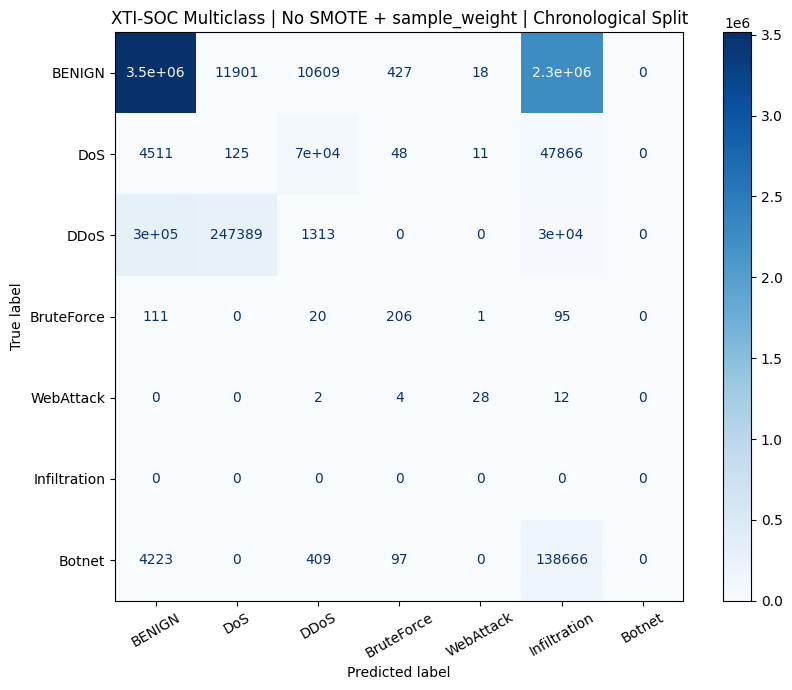

confusion_matrix_multiclass_chrono.png saved


In [9]:
target_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP.keys())]
 
# ── Evaluate using predict_proba ──────────────────────────────────────────────
proba_mc  = model_mc.predict_proba(X_test_scaled)
y_pred_mc = proba_mc.argmax(axis=1)       # same as model.predict() at 0.5 gate
max_probs  = proba_mc.max(axis=1)          # per-prediction confidence
 
print("=== MULTICLASS CLASSIFICATION REPORT (no confidence gate) ===")
print(classification_report(y_test, y_pred_mc, target_names=target_names))
 
# ── Confidence gate simulation ────────────────────────────────────────────────
# Flows where the model is not confident enough → UNKNOWN_ANOMALY in production
print(f"\n=== CONFIDENCE GATE SIMULATION (gate={MULTICLASS_CONFIDENCE_GATE}) ===")
gated     = np.where(max_probs >= MULTICLASS_CONFIDENCE_GATE, y_pred_mc, -1)
n_unknown = (gated == -1).sum()
n_total   = len(gated)
print(f"Total test flows:  {n_total:,}")
print(f"Labelled attacks:  {n_total - n_unknown:,} ({(n_total-n_unknown)/n_total*100:.1f}%)")
print(f"UNKNOWN_ANOMALY:   {n_unknown:,} ({n_unknown/n_total*100:.1f}%) ← zero-day fallback")
 
# ── Gated report (confident predictions only) ─────────────────────────────────
mask_known = gated != -1
if mask_known.sum() > 0:
    print("\n=== REPORT ON HIGH-CONFIDENCE PREDICTIONS ONLY ===")
    print(classification_report(
        y_test[mask_known], gated[mask_known],
        target_names=target_names,
        labels=list(range(len(CLASS_ORDER)))
    ))
 
# ── Infiltration and WebAttack note ──────────────────────────────────────────
print("\n--- KNOWN WEAK CLASSES (expected after chrono split + no SMOTE) ---")
print("Infiltration: fewer training samples + patterns shift between train/test days")
print("WebAttack:    only ~100 real samples total. Cannot recover without more data.")
print("These are dataset limitations, not code bugs. Document them honestly.")
 
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_mc)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
    cmap="Blues", ax=ax, xticks_rotation=30)
plt.title("XTI-SOC Multiclass | No SMOTE + sample_weight | Chronological Split")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_PATH, "confusion_matrix_multiclass_chrono.png"), dpi=150)
plt.show()
print("confusion_matrix_multiclass_chrono.png saved")


Cell 7 — Save label_map and Verify All Artifacts

In [10]:
# Save label map
with open(os.path.join(ARTIFACT_PATH, 'label_map.pkl'), 'wb') as f:
    pickle.dump(LABEL_MAP, f)
print(f"label_map.pkl saved: {LABEL_MAP}")

# Verify
print("\n=== ARTIFACT VERIFICATION ===\n")
mc_artifacts = ['model_multiclass.pkl', 'scaler_multiclass.pkl', 'label_map.pkl']
for a in mc_artifacts:
    path = os.path.join(ARTIFACT_PATH, a)
    size = os.path.getsize(path) / 1024**2
    print(f"✓ {a:30s} {size:.1f} MB")

# Reload and smoke test
with open(os.path.join(ARTIFACT_PATH, 'model_multiclass.pkl'), 'rb') as f:
    m_mc = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'scaler_multiclass.pkl'), 'rb') as f:
    sc_mc = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'label_map.pkl'), 'rb') as f:
    lm = pickle.load(f)

dummy = np.zeros((1, 25), dtype='float32')
dummy_scaled = sc_mc.transform(dummy)
pred_int = int(m_mc.predict(dummy_scaled)[0])
pred_label = lm[pred_int]

print(f"\nSmoke test: predict([[0]*25]) → class {pred_int} = '{pred_label}'")
assert lm[0] == 'BENIGN', f"BENIGN must be class 0! Got: {lm[0]}"
print("✅ label_map[0] == 'BENIGN' — confirmed")

# Confirm binary artifacts untouched
print("\n=== BINARY ARTIFACTS STILL INTACT ===")
for a in ['model.pkl', 'scaler.pkl', 'explainer.pkl', 'feature_list.pkl']:
    path = os.path.join(ARTIFACT_PATH, a)
    exists = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"{exists} {a}")

print("\n=== MULTICLASS TRAINING COMPLETE ===")
print("Ready to update ml_engine.py for two-model predict()")

label_map.pkl saved: {0: 'BENIGN', 1: 'DoS', 2: 'DDoS', 3: 'BruteForce', 4: 'WebAttack', 5: 'Infiltration', 6: 'Botnet'}

=== ARTIFACT VERIFICATION ===

✓ model_multiclass.pkl           9.3 MB
✓ scaler_multiclass.pkl          0.0 MB
✓ label_map.pkl                  0.0 MB

Smoke test: predict([[0]*25]) → class 5 = 'Infiltration'
✅ label_map[0] == 'BENIGN' — confirmed

=== BINARY ARTIFACTS STILL INTACT ===
✓ model.pkl
✓ scaler.pkl
✓ explainer.pkl
✓ feature_list.pkl

=== MULTICLASS TRAINING COMPLETE ===
Ready to update ml_engine.py for two-model predict()


=========SOMETESTS=========

In [27]:
print(model_mc)
print(model_mc.n_estimators)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_class=7, num_parallel_tree=None, ...)
300


In [28]:
from sklearn.metrics import classification_report

y_pred = model_mc.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99   1697480
           1       0.83      0.84      0.83     34589
           2       0.95      0.95      0.95    155040
           3       1.00      0.99      1.00     18954
           4       0.09      0.75      0.16        16
           5       0.55      0.03      0.06     20571
           6       1.00      0.99      1.00     28679

    accuracy                           0.98   1955329
   macro avg       0.77      0.79      0.71   1955329
weighted avg       0.98      0.98      0.98   1955329

